# Efficiency Plots for SIDM

### Set up

In [1]:
# First we need to import all the necessary libraries

import uproot
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt
import boost_histogram as bh
import hist
import vector

# We also want to import things from sidm that are not libraries pre-installed to coffea
import sys
# Tell Python to look one directory up (which should be the root of the 'sidm' project)
sys.path.append("..") 

# Now the import should work because 'sidm' is in the path
from sidm.tools import utilities

import mplhep as hep
plt.style.use(hep.style.CMS)

In [2]:
# We also need to open the file path so we have data to work with 

file_path = "root://xcache//store/user/lpcmetx/SIDM/ULSignalSamples/2024/nanoaodYear2024.root"
file = uproot.open(file_path)

In [3]:
# Let's take a look in the file
file.keys()

['tag;1',
 'Events;1',
 'LuminosityBlocks;1',
 'Runs;1',
 'MetaData;1',
 'ParameterSets;1']

In [4]:
# The data we want will be contained in the Events TTree so we'll open that one
t = file["Events"]
t.show()

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
run                  | uint32_t                 | AsDtype('>u4')
luminosityBlock      | uint32_t                 | AsDtype('>u4')
event                | uint64_t                 | AsDtype('>u8')
bunchCrossing        | uint32_t                 | AsDtype('>u4')
orbitNumber          | uint32_t                 | AsDtype('>u4')
HTXS_njets25         | uint8_t                  | AsDtype('uint8')
HTXS_njets30         | uint8_t                  | AsDtype('uint8')
HTXS_stage1_1_cat... | int32_t                  | AsDtype('>i4')
HTXS_stage1_1_cat... | int32_t                  | AsDtype('>i4')
HTXS_stage1_1_fin... | int32_t                  | AsDtype('>i4')
HTXS_stage1_1_fin... | int32_t                  | AsDtype('>i4')
HTXS_stage1_2_cat... | int32_t                  | AsDtype('>i4')
HTXS_stage1_2_cat... | int32_t                  | AsDt

### Identifying Triggers to Examine

In [5]:
# First we will define a list of all_branch_names that lets us access the trigger arrays in the Events file

#We'll define the Events object in the file

Events = file["Events"]

# We want to use the .keys() to create a simple list of all the branch names in "Events" 

all_branch_names = list(Events.keys())

# print(all_branch_names)

In [6]:
# Creating a Table for Muon Triggers (specifically looking for double muons)

# Using a for loop we can isolate the double muon Level2 triggers from the list of branches in Events
mu_hlt_triggers = []
for name in all_branch_names:
    if name.startswith("HLT_") and "DoubleL2Mu" in name:
        mu_hlt_triggers.append(name)


# Create table that prints the trigger name, number of events that pass and the pass rate

N_EVENTS = Events.num_entries # Get the total number of events

# Analyze Triggers 

analysis_results = []

for name in mu_hlt_triggers: 
    mask_array = Events[name].array()

    # Count the number of events that pass 
    passed_count = np.sum(mask_array)
    
    # Calculate the percentage of events that pass the trigger 
    pass_percentage = (passed_count / N_EVENTS) * 100
    
    # Store the results by appending them to the analysis results array
    analysis_results.append({
        "name": name,
        "count": passed_count,
        "percent": pass_percentage
    })

# Sort and Display Results

sorted_results = sorted(analysis_results, key=lambda x: x["count"], reverse=True)

# Make table

print(f"TRIGGER ANALYSIS REPORT (Total Events = {N_EVENTS})")  # title line
print("-" * 86)                                            # separate the title with a bunch of dashes

print(f"{'Trigger Name':<57} | {'Events Passed':>12}| {'Pass Rate':>10}")  # make 3 columns 
print("-" * 86)

# Print the results
for result in sorted_results:
    print(
        f"{result['name']:<57} | "
        f"{result['count']:>12,} | "  
        f"{result['percent']:>8.2f}%"
    )


TRIGGER ANALYSIS REPORT (Total Events = 9999)
--------------------------------------------------------------------------------------
Trigger Name                                              | Events Passed|  Pass Rate
--------------------------------------------------------------------------------------
HLT_DoubleL2Mu25NoVtx_2Cha_Eta2p4                         |        7,381 |    73.82%
HLT_DoubleL2Mu23NoVtx_2Cha                                |        7,246 |    72.47%
HLT_DoubleL2Mu25NoVtx_2Cha                                |        7,143 |    71.44%
HLT_DoubleL2Mu30NoVtx_2Cha_Eta2p4                         |        7,138 |    71.39%
HLT_DoubleL2Mu50                                          |        6,332 |    63.33%
HLT_DoubleL2Mu25NoVtx_2Cha_CosmicSeed_Eta2p4              |        5,579 |    55.80%
HLT_DoubleL2Mu23NoVtx_2Cha_CosmicSeed                     |        5,562 |    55.63%
HLT_DoubleL2Mu25NoVtx_2Cha_CosmicSeed                     |        5,422 |    54.23%
HLT_DoubleL2Mu

## Efficiency Plots

### Plots with LooseID applied and then masks evaluated

In [38]:
# First define some variables we will need
muons = t.arrays(
    ["Muon_pt", "Muon_eta", "Muon_phi", "Muon_mass", "Muon_charge"]
)

Muon_pt = muons["Muon_pt"]

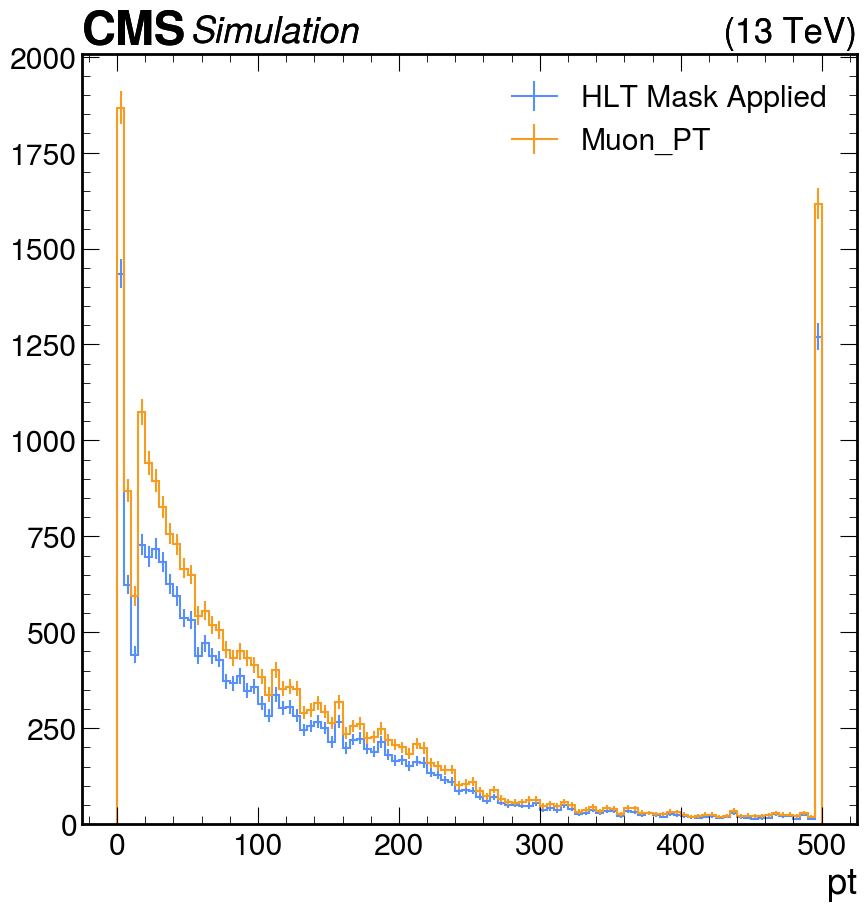

In [39]:
# Plot for HLT_DoubleL2Mu25NoVtx_2Cha_Eta2p4

HLT_DoubleL2Mu25NoVtx_2Cha_Eta2p4 = Events["HLT_DoubleL2Mu25NoVtx_2Cha_Eta2p4"].array()   # In the table made previously this had a 63.33% pass rate

#Define the histograms and the axis
pt_axis = hist.axis.Regular(100, 0, 500, name="pt")
numerator = hist.Hist(pt_axis)
denominator = hist.Hist(pt_axis)

#Fill the histograms with the flattened arrays
numerator.fill(ak.flatten(Muon_pt[HLT_DoubleL2Mu25NoVtx_2Cha_Eta2p4]))
denominator.fill(ak.flatten(Muon_pt))

#Plot both on the same figure
utilities.plot(numerator, label = "HLT Mask Applied")
utilities.plot(denominator, label ="Muon_PT")
plt.legend(loc = 'upper right')


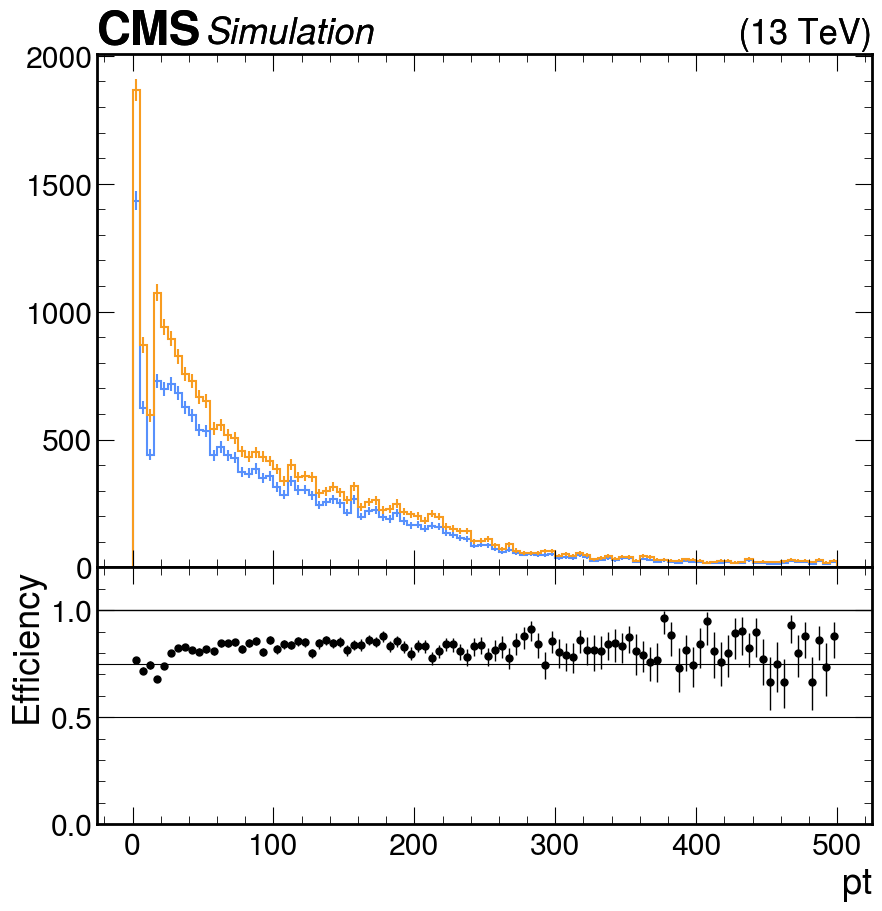

In [36]:
#Plot both along with their ratio. The warnings occur if there are any bins with zero counts and can be safely ignored. 
#If the numerator is ever greater than the denominator in any bin, this will throw an error

plot_result = utilities.plot_ratio(numerator, denominator)

# Use a for loop to check if the plot function failed to return the axes objects (returned None)
if plot_result is None:
    # Handle the failure: retrieve axes from Matplotlib's global state
    fig = plt.gcf()
    all_axes = fig.get_axes()
    if len(all_axes) >= 2:
        ratio_ax = all_axes[1]
    else:
        # Exit if plot still isn't usable
        print("ERROR: Could not retrieve axes from figure.")
        ratio_ax = None
else:
    # Handle the success: unpack the returned objects
    fig, (ax1, ratio_ax) = plot_result
    
# 3. Apply the horizontal line if the ratio axis was successfully retrieved
if ratio_ax is not None:

    # Line 1: The original thin black line at 0.5 (Solid)
    ratio_ax.axhline(y=0.5, color='black', linestyle='-', linewidth=0.8)
    
    # Line 2: A dashed, slightly thicker gray line at 1
    ratio_ax.axhline(y=1, color='black', linestyle='-', linewidth=1)
    
    # Line 3: A dotted red line at 0.75 (perhaps a warning boundary)
    ratio_ax.axhline(y=0.75, color='black', linestyle='-', linewidth=0.8)
    

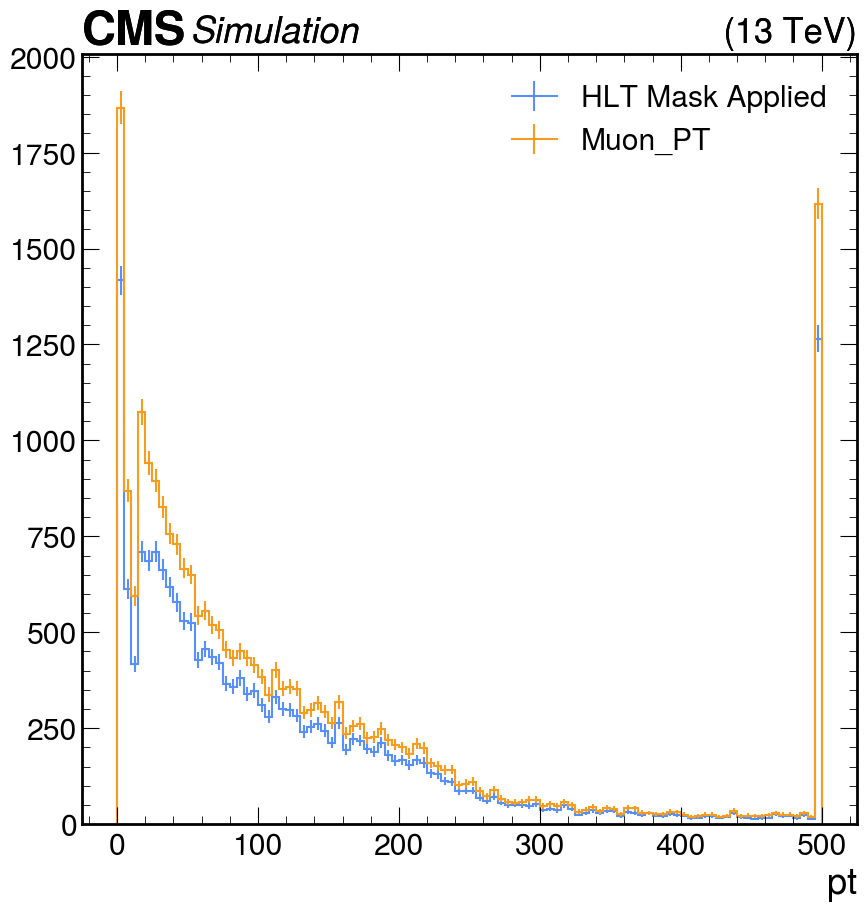

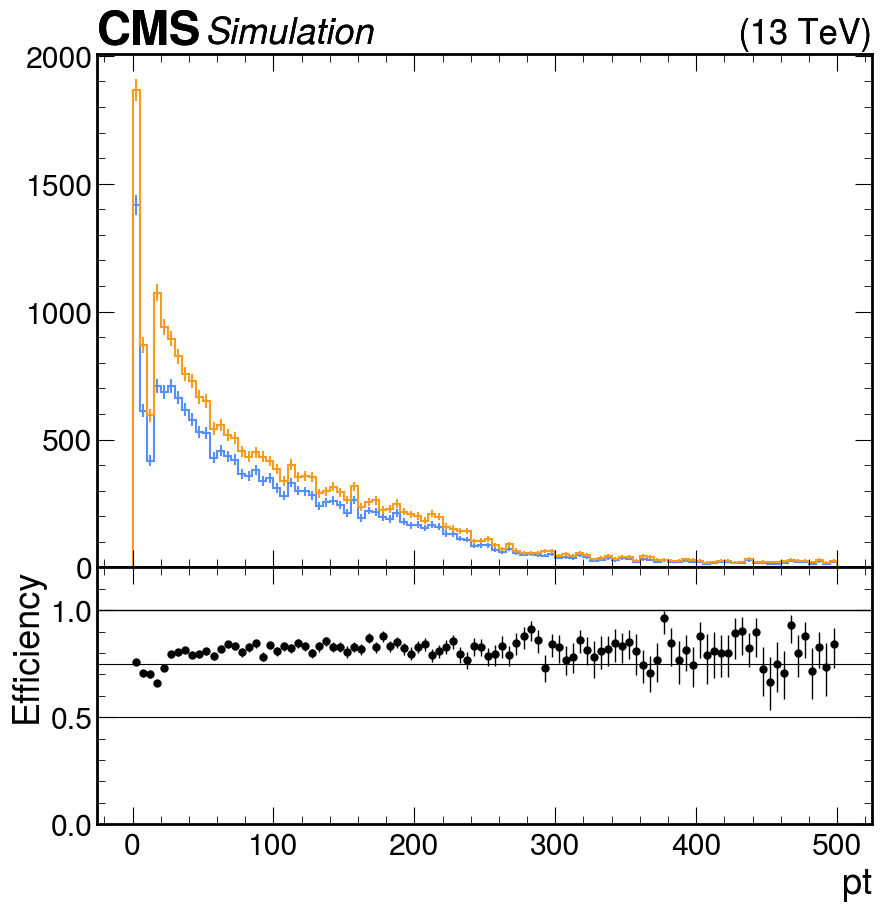

In [37]:
# Plot for HLT_DoubleL2Mu23NoVtx_2Cha

# Now define the mask we will use

HLT_DoubleL2Mu23NoVtx_2Cha = Events["HLT_DoubleL2Mu23NoVtx_2Cha"].array()   # In the table made previously this had a 63.33% pass rate

#Define the histograms and the axis
pt_axis = hist.axis.Regular(100, 0, 500, name="pt")
numerator = hist.Hist(pt_axis)
denominator = hist.Hist(pt_axis)

#Fill the histograms with the flattened arrays
numerator.fill(ak.flatten(Muon_pt[HLT_DoubleL2Mu23NoVtx_2Cha]))
denominator.fill(ak.flatten(Muon_pt))

#Plot both on the same figure
utilities.plot(numerator, label = "HLT Mask Applied")
utilities.plot(denominator, label = "Muon_PT")
plt.legend(loc = 'upper right')

#Plot both along with their ratio. The warnings occur if there are any bins with zero counts and can be safely ignored. 
#If the numerator is ever greater than the denominator in any bin, this will throw an error

plot_result = utilities.plot_ratio(numerator, denominator)

# Use a for loop to check if the plot function failed to return the axes objects (returned None)
if plot_result is None:
    # Handle the failure: retrieve axes from Matplotlib's global state
    fig = plt.gcf()
    all_axes = fig.get_axes()
    if len(all_axes) >= 2:
        ratio_ax = all_axes[1]
    else:
        # Exit if plot still isn't usable
        print("ERROR: Could not retrieve axes from figure.")
        ratio_ax = None
else:
    # Handle the success: unpack the returned objects
    fig, (ax1, ratio_ax) = plot_result
    
# 3. Apply the horizontal line if the ratio axis was successfully retrieved
if ratio_ax is not None:

    # Line 1: The original thin black line at 0.5 (Solid)
    ratio_ax.axhline(y=0.5, color='black', linestyle='-', linewidth=0.8)
    
    # Line 2: A dashed, slightly thicker gray line at 1
    ratio_ax.axhline(y=1, color='black', linestyle='-', linewidth=1)
    
    # Line 3: A dotted red line at 0.75 (perhaps a warning boundary)
    ratio_ax.axhline(y=0.75, color='black', linestyle='-', linewidth=0.8)
    